In [1]:
import pyabf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.stats import gaussian_kde

In [2]:
laser_ma = {8: 500, 9: 700, 10: 900, 11: 1000, 12: 1100, 13: 1200, 14: 1400}
archivos = [8, 9, 10, 11, 12, 13, 14]
fases = ["control", "laser", "rec"]
colores = {"control": "#1a6fad", "laser": "#c0392b", "rec": "#2e7d32"}

ruta_base = r"C:\Users\Usuario\Documents\TFG\Experimento ABRIL 2026\27042026 patch"
ruta_analisis = r"C:\Users\Usuario\Documents\TFG\Experimento ABRIL 2026\ANÁLISIS"

FASE_DURACION = 150

archivos_info = {
    8:  {"control": (0, 163.1), "laser": (163.1, 314.8), "rec": (314.8, 480.0)},
    9:  {"control": (0, 154.3), "laser": (154.3, 310.3), "rec": (310.3, 480.0)},
    10: {"control": (0, 155.6), "laser": (155.6, 311.4), "rec": (311.4, 480.0)},
    11: {"control": (0, 152.1), "laser": (152.1, 304.9), "rec": (304.9, 480.0)},
    12: {"control": (0, 156.4), "laser": (156.4, 314.4), "rec": (314.4, 480.0)},
    13: {"control": (0, 153.7), "laser": (153.7, 314.3), "rec": (314.3, 480.0)},
    14: {"control": (0, 152.9), "laser": (152.9, 307.8), "rec": (307.8, 480.0)},
}

## Cálculo de latencia al primer AP

= tiempo desde el inicio del pulso hasta el primer AP detectado en ese pulso.
Solo se incluyen los pulsos que generan al menos un AP.

In [5]:
lat_ctrl  = []
lat_laser = []
lat_rec = []

for num in archivos:
    abf = pyabf.ABF(rf"{ruta_base}\264270{num:02d}.abf")
    abf.setSweep(0, channel=0)
    tiempo = abf.sweepX
    vm = abf.sweepY
    fs = abf.dataRate

    for fase in fases:
        t0 = archivos_info[num][fase][0]
        mask = (tiempo >= t0) & (tiempo <= t0 + FASE_DURACION)
        t_fase = tiempo[mask]
        vm_fase = vm[mask]

        reposo = np.median(vm_fase)
        umbral = reposo + 10
        por_encima = (vm_fase > umbral).astype(int)
        flancos_subida = np.where(np.diff(por_encima) == 1)[0]
        flancos_bajada = np.where(np.diff(por_encima) == -1)[0]

        picos, _ = find_peaks(vm_fase, height=0, distance=int(0.05 * fs))
        t_picos = t_fase[picos]

        i = 0
        while i < len(flancos_subida):
            t_ini = t_fase[flancos_subida[i]]
            bajadas_validas = flancos_bajada[flancos_bajada > flancos_subida[i]]
            if len(bajadas_validas) > 0:
                t_fin = t_fase[bajadas_validas[0]]
                picos_pulso = t_picos[(t_picos >= t_ini) & (t_picos <= t_fin + 0.5)]
                if len(picos_pulso) > 0:
                    latencia = (picos_pulso[0] - t_ini) * 1000
                    if fase == "control":
                        lat_ctrl.append(latencia)
                    elif fase == "laser":
                        lat_laser.append(latencia)
                    else:
                        lat_rec.append(latencia)
            i += 1
            while i < len(flancos_subida) and t_fase[flancos_subida[i]] - t_ini < 2.0:
                i += 1

print(f"Control → media = {np.mean(lat_ctrl):.1f} ms | std = {np.std(lat_ctrl):.1f} ms | mediana = {np.median(lat_ctrl):.1f} ms | n = {len(lat_ctrl)}")
print(f"Láser → media = {np.mean(lat_laser):.1f} ms | std = {np.std(lat_laser):.1f} ms | mediana = {np.median(lat_laser):.1f} ms | n = {len(lat_laser)}")
print(f"Recuperación → media = {np.mean(lat_rec):.1f} ms | std = {np.std(lat_rec):.1f} ms | mediana = {np.median(lat_rec):.1f} ms | n = {len(lat_rec)}")

Control → media = 18.9 ms | std = 4.9 ms | mediana = 18.4 ms | n = 313
Láser → media = 157.0 ms | std = 117.1 ms | mediana = 165.1 ms | n = 162
Recuperación → media = 19.7 ms | std = 16.7 ms | mediana = 17.8 ms | n = 314


## Diagrama de violines

La distribución de latencias en la fase de láser es muy dispersa porque el láser bloquea
el primer disparo en muchos pulsos y lo retrasa al segundo intento, con latencias de hasta 400 ms.

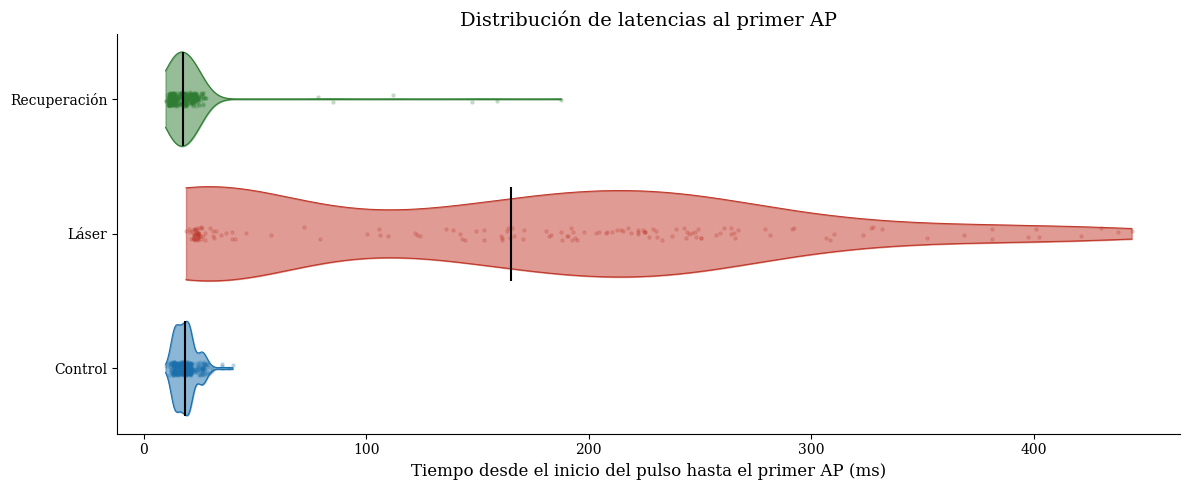

In [6]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'

datos_violin  = [lat_ctrl, lat_laser, lat_rec]
labels_violin = ["Control", "Láser", "Recuperación"]
colores_lista = [colores["control"], colores["laser"], colores["rec"]]

fig, ax = plt.subplots(figsize=(12, 5))

for pos, (datos, col, label) in enumerate(zip(datos_violin, colores_lista, labels_violin)):
    datos = np.array(datos)
    kde = gaussian_kde(datos)
    x_range = np.linspace(datos.min(), datos.max(), 300)
    densidad = kde(x_range)
    densidad = densidad / densidad.max() * 0.35

    ax.fill_between(x_range, pos - densidad, pos + densidad, color=col, alpha=0.5)
    ax.plot(x_range, pos - densidad, color=col, linewidth=0.8)
    ax.plot(x_range, pos + densidad, color=col, linewidth=0.8)
    ax.scatter(datos, pos + np.random.uniform(-0.05, 0.05, len(datos)), color=col, alpha=0.2, s=5)
    ax.vlines(np.median(datos), pos - 0.35, pos + 0.35, color='black', linewidth=1.5)

ax.set_yticks([0, 1, 2])
ax.set_yticklabels(labels_violin, fontsize=10)
ax.set_xlabel("Tiempo desde el inicio del pulso hasta el primer AP (ms)", fontsize=12)
ax.set_title("Distribución de latencias al primer AP", fontsize=14)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## Clasificación por slots

Viendo la gráfica, usamso un corte de 100 ms para separar los disparos en primer intento (slot 1), de los retrasados al segundo intento (slot 2).
Los pulsos que no generan ningún AP se cuentan como silentes.

In [7]:
CORTE_MS = 100 #ms desde el inicio de pulso, para el slot 1

resultados = {}

for num in archivos:
    abf = pyabf.ABF(rf"{ruta_base}\264270{num:02d}.abf")
    abf.setSweep(0, channel=0)
    tiempo = abf.sweepX
    vm = abf.sweepY
    fs = abf.dataRate

    resultados[num] = {}

    for fase in fases:
        t0 = archivos_info[num][fase][0]
        mask = (tiempo >= t0) & (tiempo <= t0 + FASE_DURACION)
        t_fase  = tiempo[mask]
        vm_fase = vm[mask]

        reposo = np.median(vm_fase)
        umbral = reposo + 10
        por_encima = (vm_fase > umbral).astype(int)
        flancos_subida = np.where(np.diff(por_encima) == 1)[0]
        flancos_bajada = np.where(np.diff(por_encima) == -1)[0]

        pulsos = []
        i = 0
        while i < len(flancos_subida):
            t_ini = t_fase[flancos_subida[i]]
            bajadas_validas = flancos_bajada[flancos_bajada > flancos_subida[i]]
            if len(bajadas_validas) > 0:
                pulsos.append((t_ini, t_fase[bajadas_validas[0]]))
            i += 1
            while i < len(flancos_subida) and t_fase[flancos_subida[i]] - t_ini < 2.0:
                i += 1

        picos, _ = find_peaks(vm_fase, height=0, distance=int(0.05 * fs))
        t_picos  = t_fase[picos]

        slot1, slot2, sin_ap = 0, 0, 0
        for t_ini, t_fin in pulsos:
            picos_pulso = t_picos[(t_picos >= t_ini) & (t_picos <= t_fin + 0.5)]
            if len(picos_pulso) == 0:
                sin_ap += 1
            elif (picos_pulso[0] - t_ini) * 1000 < CORTE_MS:
                slot1 += 1
            else:
                slot2 += 1

        total = slot1 + slot2 + sin_ap
        resultados[num][fase] = {
            "slot1": slot1, "slot1_pct":  round(slot1  / total * 100, 1),
            "slot2": slot2, "slot2_pct":  round(slot2  / total * 100, 1),
            "sin_ap": sin_ap, "sin_ap_pct": round(sin_ap / total * 100, 1),
            "total": total,
        }

# Tabla
filas = []
for num in archivos:
    for fase in fases:
        r = resultados[num][fase]
        filas.append({
            "archivo": num,
            "intensidad (mA)": laser_ma[num],
            "fase": fase,
            "total pulsos": r["total"],
            "slot1 (n)": r["slot1"],"slot1 (%)": r["slot1_pct"],
            "slot2 (n)": r["slot2"], "slot2 (%)": r["slot2_pct"],
            "sin AP (n)": r["sin_ap"], "sin AP (%)": r["sin_ap_pct"],
        })

df_lat = pd.DataFrame(filas)
df_lat

,archivo,intensidad (mA),fase,total pulsos,slot1 (n),slot1 (%),slot2 (n),slot2 (%),sin AP (n),sin AP (%)
0,8,500,control,45,45,100.0,0,0.0,0,0.0
1,8,500,laser,45,45,100.0,0,0.0,0,0.0
2,8,500,rec,44,44,100.0,0,0.0,0,0.0
3,9,700,control,44,44,100.0,0,0.0,0,0.0
4,9,700,laser,45,6,13.3,9,20.0,30,66.7
5,9,700,rec,45,42,93.3,3,6.7,0,0.0
6,10,900,control,45,45,100.0,0,0.0,0,0.0
7,10,900,laser,45,8,17.8,37,82.2,0,0.0
8,10,900,rec,45,45,100.0,0,0.0,0,0.0
9,11,1000,control,45,45,100.0,0,0.0,0,0.0
